# Mean-field solvers with automatic differentiation

Instead of plain linear mixing, `use_jax=True` builds a JAX-differentiable version of one SCF
iteration $x=f(x)$ and drives it to its fixed point with a genuine root-finder using JAX-computed
derivatives of $f$: Newton's method (`solver="newton"`, the default), a matrix-free
`"newton_krylov"` variant that scales to larger systems, matrix-free Levenberg-Marquardt residual
minimization (`solver="error_gradient"`), or a robust black-box multisecant mixing scheme
(`solver="broyden_mixing"`). Needs the optional `jax` extra (`pip install pyqula[jax]`). Below, the
JAX Newton solver is checked against the default plain-mixing numpy engine on the same biased
Hamiltonian.

converged: True True
total energy, numpy engine: -3.3077536750907215
total energy, jax newton  : -3.3077536750907215


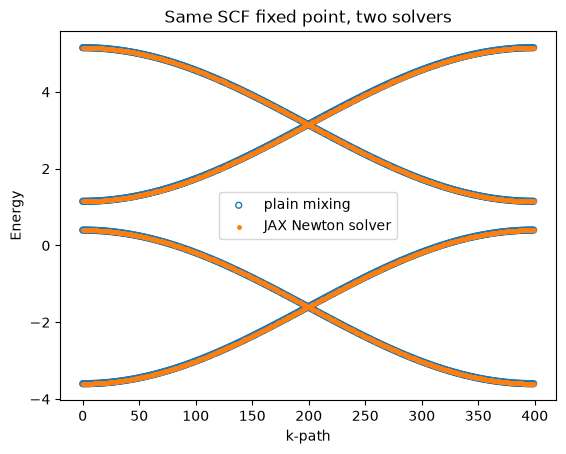

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula.meanfield import VJinteraction

def biased_hamiltonian_and_guess(seed,bias=0.8):
    g = geometry.bichain()
    h0 = g.get_hamiltonian()
    rng = np.random.default_rng(seed)
    v = rng.random(3) - .5
    v = 2*v/np.sqrt(v.dot(v))
    mf = h0.copy() ; mf.add_exchange([v,-v])
    h1 = h0.copy() ; h1.add_exchange(bias*v)
    return h1,mf

h1,mf0 = biased_hamiltonian_and_guess(seed=0)
scf_np = VJinteraction(h1.copy(),nk=20,mu=0.0,U=2.0,mf=mf0.copy(),maxerror=1e-6,verbose=0)
scf_jax = VJinteraction(h1.copy(),nk=20,mu=0.0,U=2.0,mf=mf0.copy(),maxerror=1e-6,verbose=0,
                         use_jax=True,solver="newton")

print("converged:",scf_np.converged,scf_jax.converged)
print("total energy, numpy engine:",scf_np.total_energy)
print("total energy, jax newton  :",scf_jax.total_energy)

(k1,e1) = scf_np.hamiltonian.get_bands()
(k2,e2) = scf_jax.hamiltonian.get_bands()
plt.scatter(k1,e1,s=18,facecolors="none",edgecolors="C0",label="plain mixing")
plt.scatter(k2,e2,s=6,c="C1",label="JAX Newton solver")
plt.legend()
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("Same SCF fixed point, two solvers")
plt.show()

The same comparison as a map: the momentum-resolved spectral function of the state found by the
JAX Newton solver, with the bands of the plain-mixing solution drawn on top as dots, which sit on
its maxima.

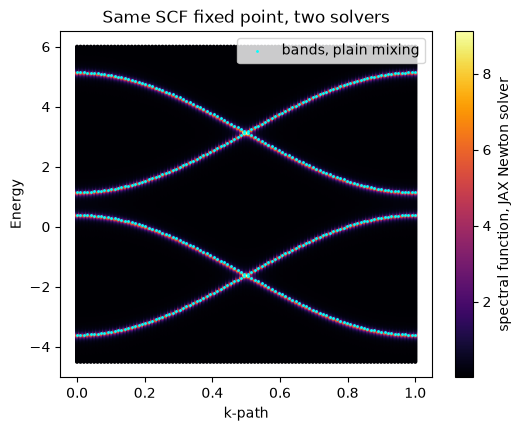

In [2]:
(k,e,d) = scf_jax.hamiltonian.get_kdos_bands(energies=np.linspace(-4.5,6.,300),delta=5e-2) # JAX solution
(k1,e1) = scf_np.hamiltonian.get_bands(nk=100) # plain-mixing solution, on the same k-path

plt.figure(figsize=(6,4.5))
plt.scatter(k/np.max(k),e,c=d,cmap="inferno",s=4)
plt.colorbar(label="spectral function, JAX Newton solver")
plt.scatter(k1/np.max(k1),e1,s=1,c="cyan",label="bands, plain mixing")
plt.legend(loc="upper right")
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("Same SCF fixed point, two solvers")
plt.show()